## Librairies and functions

In [1]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Postdoc\Compressed_sensing\compressed_sensing_bioacoustics\src


In [2]:
from model import Model

c:\Users\loren\anaconda3\envs\cs_HeAims\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import torch
import gc

In [4]:
from sklearn.metrics import confusion_matrix,f1_score
import torch
import numpy as np
import pandas as pd
import os

In [5]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load the dataset
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
        else : 
            print("load baseline")
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)


        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
            Y = pickle.load(f)
        
        print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}")
        return X, Y



In [6]:
def predictions(model, inputs, batch_size):
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        prediction_list = []
        model = model.to(device)
        model.eval()
        #np.save("inputs.npy", inputs)
        X_tensor = torch.from_numpy(inputs).float()

        # Reshape X_tensor
        # print("X_TENSOR SHAPE", X_tensor.shape)
        if len(X_tensor.shape) == 3:
            X_tensor = X_tensor.unsqueeze(1)

        loader = torch.utils.data.DataLoader(
            X_tensor, batch_size=batch_size, shuffle=False
        )

        all_preds = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                logits = model(batch)
                preds = logits.argmax(dim=1)
                all_preds.append(preds.cpu())


        return torch.cat(all_preds).numpy()

## Parameters

In [7]:
selected_species = "bats" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: bats
{'sample_rate': 256000, 'lowpass_cutoff': 2000, 'downsample_rate': 128000, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 20, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 512, 'hop_length': 384, 'n_mels': 128, 'f_min': 15000, 'f_max': 64000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Bats'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'bats', 'negative_class': ''}


In [8]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats"
config.preprocessing.audio_extension=".flac"

method_compression="flac"
parameter_compression="0"

In [9]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\results\bats_flac_0


#### Architecture of the model

In [8]:
config.cnn_architecture.dict()

{'conv_layers': 2,
 'conv_filters': 16,
 'dropout_rate': 0.5,
 'conv_kernel': 16,
 'max_pooling_size': 4,
 'fc_units': 32,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None,
 'num_classes': 4}

In [10]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64

In [11]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64


In [12]:
#Gibbon : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 8
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=128

In [10]:
#Bats
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 16
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=32

## Training

In [12]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
#X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats/train


In [13]:
#print(f"Val set size: {len(X_val)}")
print(f"Train set size: {len(X_train)}")

Train set size: 5045


In [14]:
X_train.shape

(5045, 128, 334)

In [ ]:
del model

In [16]:

if selected_species=="bats":
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            task="classification",
            **config.model.dict(),
        )
else : 
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )



In [17]:
model

BaseCNN(
  (conv_layers): Sequential(
    (conv0): Conv2d(1, 16, kernel_size=(16, 16), stride=(1, 1))
    (bn0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.5, inplace=False)
    (maxpool0): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (conv1): Conv2d(16, 16, kernel_size=(16, 16), stride=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.5, inplace=False)
    (maxpool1): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (fc0): Linear(in_features=768, out_features=32, bias=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.5, inplace=False)
    (fc1): Linear(in_features=32, out_features=32, bias=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.5, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_

In [18]:
"""
n_neg = 7084
n_pos = 2491

class_weights = [1.0, n_neg / n_pos]  # [1.0, 2.84]
"""

if method_compression!=None:
    model_name=method_compression+"_"+parameter_compression
else : 
    model_name="baseline"

if  selected_species == "bats":
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)
else : 
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)



Training:  46%|████▌     | 23/50 [02:57<03:28,  7.72s/epoch, lr=1.00e-03, train_loss=0.8359, val_loss=0.8879, best_val=0.8431]

Early stopping triggered at epoch 24


#### plot val and train loss

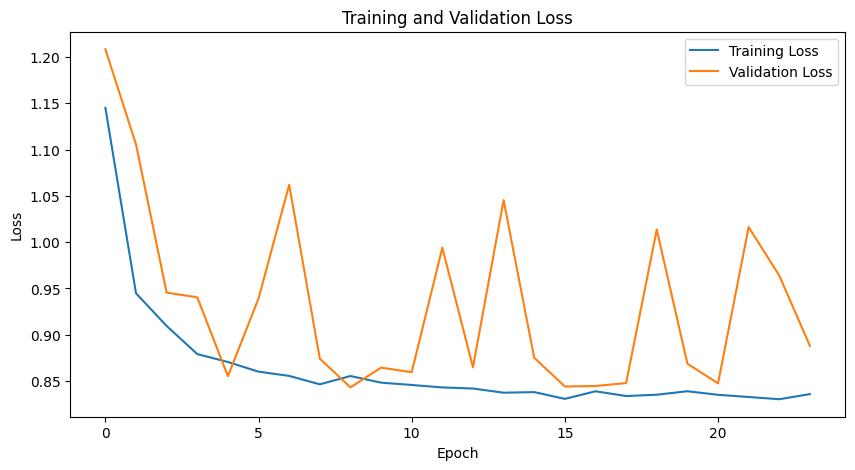

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot( val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [20]:
baseline_metric, baseline_metric_name = model.evaluate(
            X_val=X_train, Y_val=Y_train, print_report=True
        )

print(baseline_metric)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1343
           1       0.69      0.80      0.74       605
           2       0.99      0.66      0.79      1628
           3       0.85      0.99      0.92      1469

    accuracy                           0.85      5045
   macro avg       0.84      0.85      0.84      5045
weighted avg       0.87      0.85      0.85      5045

[[1298    4    6   35]
 [  12  487    7   99]
 [ 243  198 1068  119]
 [   1   15    0 1453]]
0.8359843221733754


# Evaluation of the model for bats

In [23]:
X_test, Y_test=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats/test


In [25]:
method_compression

'flac'

In [29]:
#load the saved model
if method_compression!= None :
    model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
else : 
    model_name="baseline_cnn_state.pth"
model_path = os.path.join(save_path, model_name)
print(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model.load_cnn(model_path, device)

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\results\bats_flac_0\flac_0_cnn_state.pth


In [31]:
preds=predictions(model, X_test, batch_size=62)

In [32]:
preds

array([0, 0, 0, ..., 3, 3, 3])

In [33]:
cnf_matrix = confusion_matrix(Y_test, preds)
print(cnf_matrix)

[[ 632    0   29   18]
 [  28  240   11   70]
 [1153   36 5716  168]
 [  18    3    0 1009]]


In [34]:
TP=np.diag(cnf_matrix)
FP=np.sum(cnf_matrix,axis=1)-TP
FN=np.sum(cnf_matrix,axis=0)-TP
TN=np.ones(4)*np.sum(cnf_matrix)-TP-FP-FN

Accuracy=(TP+TN)/(TP+TN+FP+FN)
Recall=TP/(TP+FN)
Precision =TP/(TP+FP)
Specificity =TN/(TN+FP)
F1_score=2*(Recall*Precision)/ (Recall+Precision)


In [35]:
labels=['CISTUGO','CNEHOT','LAEDEG','TADAEG']
df = pd.DataFrame({'Accuracy': Accuracy, 'Recall': Recall, 'Precision': Precision, 'Specificity': Specificity, 'F1_score': F1_score},
                      index = labels)
df


,Accuracy,Recall,Precision,Specificity,F1_score
CISTUGO,0.863542,0.345167,0.930781,0.993562,0.503586
CNEHOT,0.983791,0.860215,0.687679,0.987686,0.764331
LAEDEG,0.847005,0.993051,0.808144,0.597926,0.891106
TADAEG,0.969664,0.797628,0.979612,0.997330,0.879303


In [36]:
Global_accuracy=(np.sum(TP)+np.sum(TN))/(np.sum(TP)+np.sum(TN)+np.sum(FP)+np.sum(FN))
print("Global Accuracy :", Global_accuracy)

F1_score=np.mean(df['F1_score'])
print("F1-score :", F1_score)

f1 = f1_score(Y_test, preds, average="macro")
print(f1)

Global Accuracy : 0.9160004380681196
F1-score : 0.7595814468938764
0.7595814468938765


## Evaluation of the model

In [ ]:
from evaluation import Evaluation
from model import Model
import torch
import os

In [ ]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())


In [ ]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"
config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.2"

if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    model_name="baseline_cnn_state.pth"
print(save_path)

In [ ]:
model_path = os.path.join(save_path, model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model.load_cnn(model_path, device)

In [ ]:
overlap=0.10
nb_to_group=0
threshold=0.8
step_size=1

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                step_size=step_size,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

In [ ]:
evaluation.run(model, type="val", test_type="testing_dataset")

In [ ]:
evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

# Loop CNN for BATS

In [11]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_test, Y_test=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test",method_compression=method_compression, parameter_compression=parameter_compression)


Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats/train
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats/test


0
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training: 100%|██████████| 50/50 [04:27<00:00,  5.34s/epoch, lr=1.00e-03, train_loss=0.8243, val_loss=0.8153, best_val=0.8019]


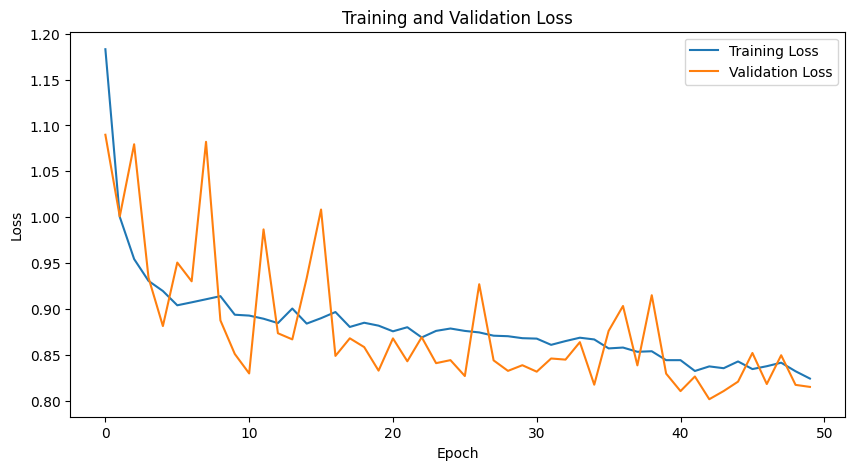

[[ 586    7   44   42]
 [   5  301   16   27]
 [ 273  147 6503  150]
 [   0    5    1 1024]]
F1-score : 0.8396071395993967
1
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training: 100%|██████████| 50/50 [04:06<00:00,  4.93s/epoch, lr=1.00e-03, train_loss=0.8152, val_loss=0.8277, best_val=0.8042]


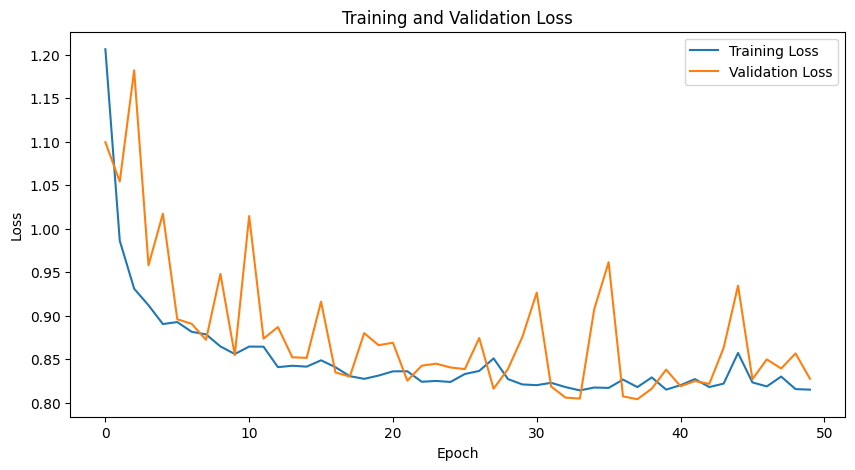

[[ 620    6   39   14]
 [   6  321   15    7]
 [ 368  336 6277   92]
 [   0   16    1 1013]]
F1-score : 0.8104791251611903
2
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  74%|███████▍  | 37/50 [03:25<01:12,  5.56s/epoch, lr=1.00e-03, train_loss=0.8122, val_loss=0.9474, best_val=0.8153]


Early stopping triggered at epoch 38


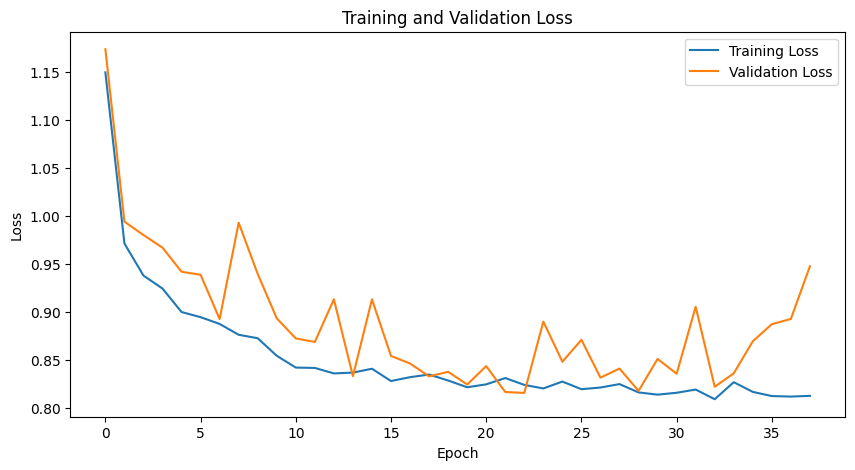

[[ 581   21   49   28]
 [   6  294   17   32]
 [ 276  246 6438  113]
 [   0    6    1 1023]]
F1-score : 0.8157310946426971
3
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  78%|███████▊  | 39/50 [03:43<01:03,  5.73s/epoch, lr=1.00e-03, train_loss=0.8220, val_loss=0.8577, best_val=0.8207]


Early stopping triggered at epoch 40


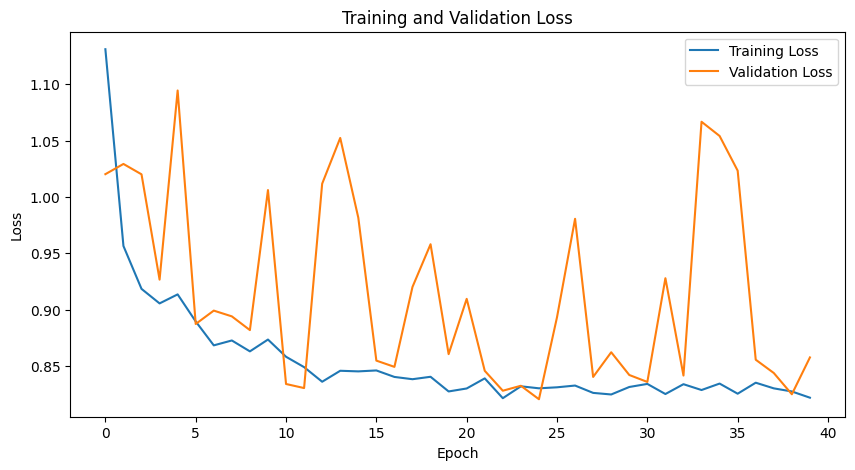

[[ 621    0   32   26]
 [  16  274   17   42]
 [ 505   63 6244  261]
 [   0    6    1 1023]]
F1-score : 0.8167833637301245
4
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  88%|████████▊ | 44/50 [04:18<00:35,  5.87s/epoch, lr=1.00e-03, train_loss=0.8317, val_loss=0.8427, best_val=0.8130]


Early stopping triggered at epoch 45


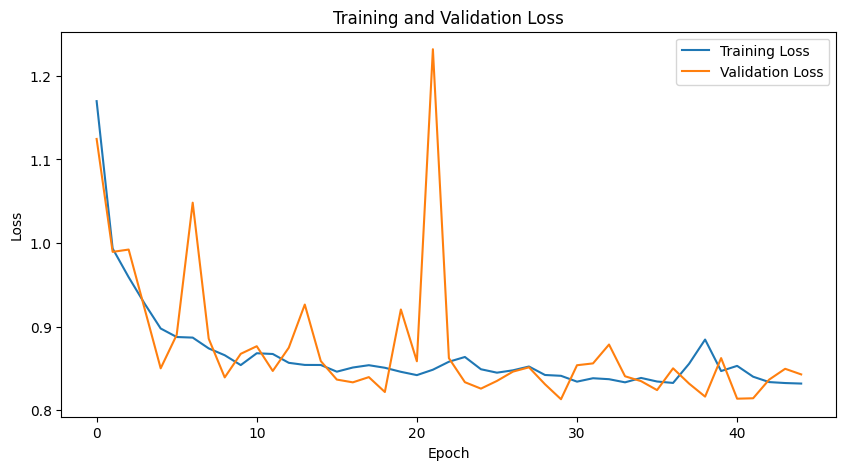

[[ 591    0   70   18]
 [  11  287   21   30]
 [ 240    8 6653  172]
 [   2    3    1 1024]]
F1-score : 0.8817084750461102
5
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training: 100%|██████████| 50/50 [04:40<00:00,  5.60s/epoch, lr=1.00e-03, train_loss=0.8278, val_loss=0.8094, best_val=0.8013]


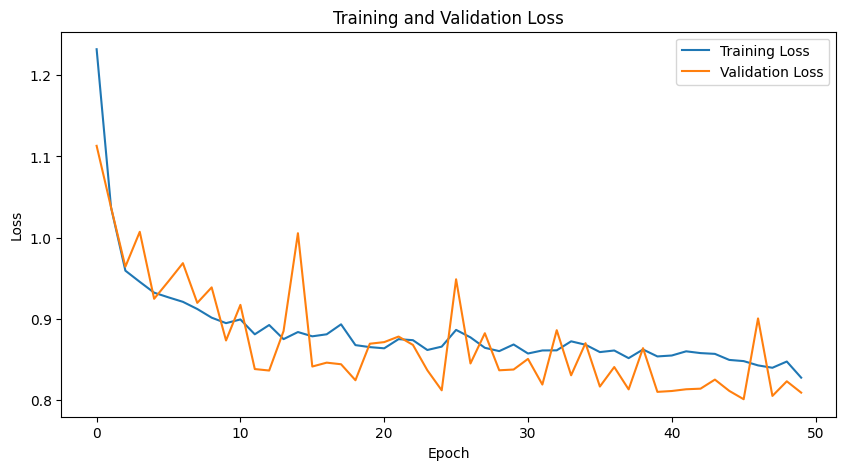

[[ 638    0   31   10]
 [   8  310   17   14]
 [ 440   57 6506   70]
 [   1   18    4 1007]]
F1-score : 0.8667271146852346
6
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training: 100%|██████████| 50/50 [04:40<00:00,  5.60s/epoch, lr=1.00e-03, train_loss=0.8033, val_loss=0.8361, best_val=0.8016]


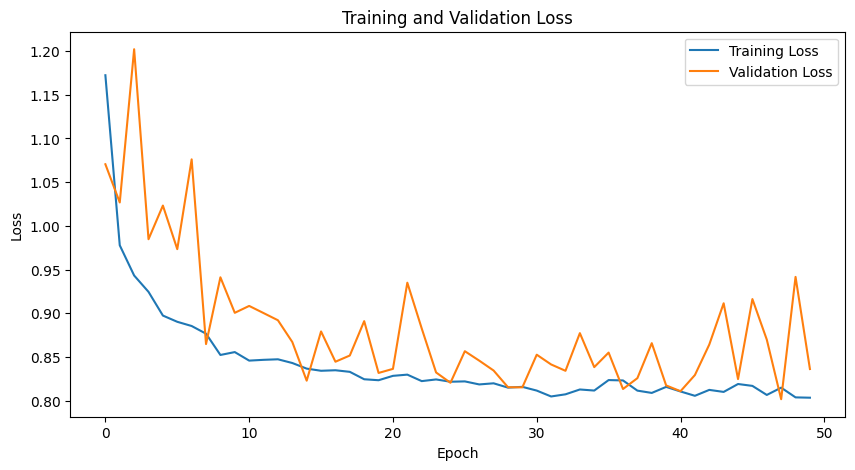

[[ 598    1   74    6]
 [   4  316   16   13]
 [ 230  128 6633   82]
 [   2   25    1 1002]]
F1-score : 0.8657976073888063
7
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  96%|█████████▌| 48/50 [04:35<00:11,  5.73s/epoch, lr=1.00e-03, train_loss=0.8068, val_loss=0.8173, best_val=0.8023]

Early stopping triggered at epoch 49


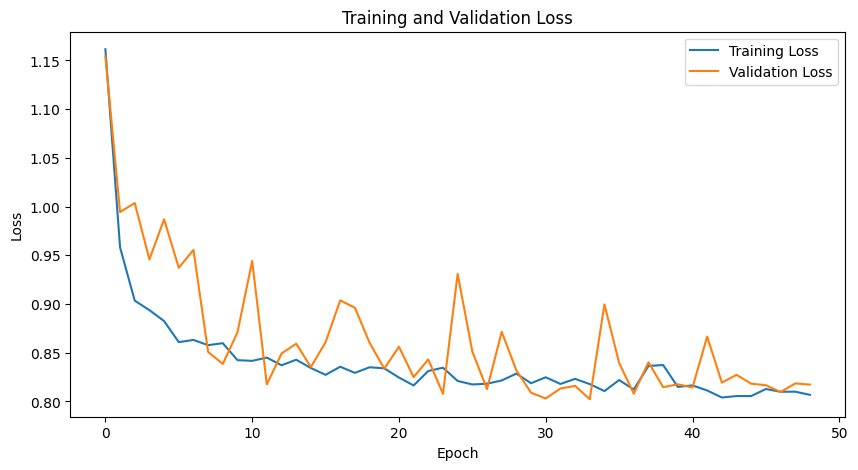

[[ 607    2   51   19]
 [   3  307   19   20]
 [ 290   62 6589  132]
 [   0   41    1  988]]
F1-score : 0.8594889613346246
8
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  86%|████████▌ | 43/50 [04:21<00:42,  6.09s/epoch, lr=1.00e-03, train_loss=0.8202, val_loss=0.8199, best_val=0.8051]


Early stopping triggered at epoch 44


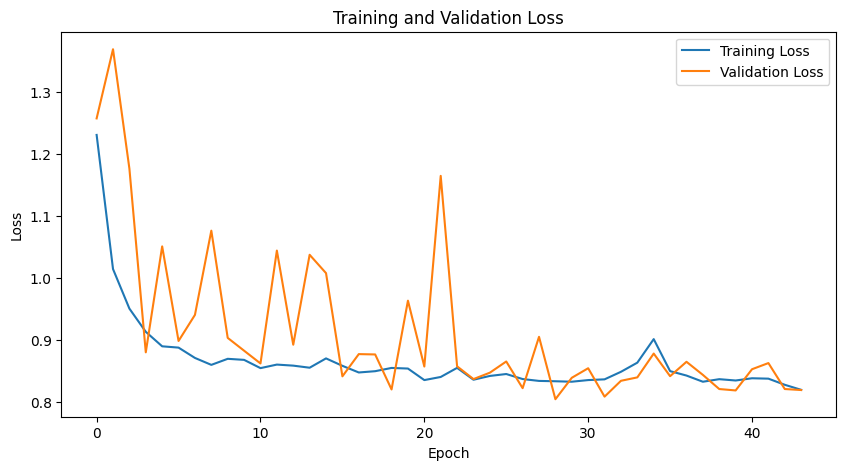

[[ 597   12   42   28]
 [   6  298   17   28]
 [ 300  179 6475  119]
 [   0   16    2 1012]]
F1-score : 0.8292886726560316
9
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 50, 'batch_size': 32, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training: 100%|██████████| 50/50 [05:12<00:00,  6.25s/epoch, lr=1.00e-03, train_loss=0.8190, val_loss=0.8252, best_val=0.8091]


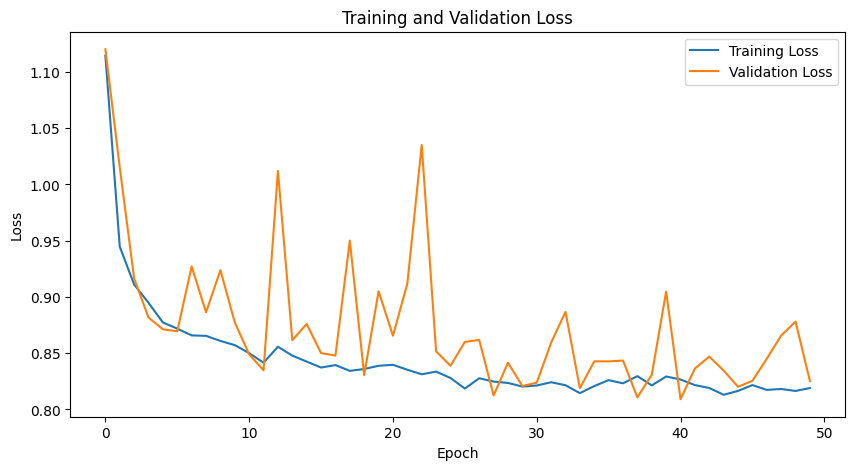

[[ 603    9   37   30]
 [   2  322   16    9]
 [ 362  253 6330  128]
 [   0   27    1 1002]]
F1-score : 0.8139040695023062
F1_score mean :  0.8399515623746522


In [12]:
first_loop=0
last_loop=10

F1_score_full=[]
F1_score=[]

for i in range(first_loop, last_loop): 
    
    
    #clean gpu
    torch.cuda.empty_cache()
    gc.collect()
    
    
    print(i)

    
    #I- Training
    #initialise the model 
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            task="classification",
            **config.model.dict(),
        )
    print(config.model.dict())

    #train
    if method_compression!= None : 
        model_name=method_compression+"_"+parameter_compression
    else : 
        model_name="baseline"
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)
    del model, model_name


    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot( val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig(Path(save_path, f"Training_and_Validation_Loss_{i}.png"))
    plt.show()
    


    # II- Evaluation
    #load the saved model
    if method_compression!= None :
        model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
    else : 
        model_name="baseline_cnn_state.pth"
    model_path = os.path.join(save_path, model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Model.load_cnn(model_path, device)

    preds=predictions(model, X_test, batch_size=62)
    cnf_matrix = confusion_matrix(Y_test, preds)
    print(cnf_matrix)

    f1 = f1_score(Y_test, preds, average="macro")
    print("F1-score :", f1)

    F1_score.append(f1)
    del model, model_name


#save f1 score
df = pd.DataFrame({"F1_score" : np.asarray(F1_score)})
df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

print("F1_score mean : ", np.mean(np.asarray(F1_score))) 



## Calculation of the threshold 

In [ ]:
thresholds=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
Precision=[]
Recall=[]
overlap=0.10
nb_to_group=0
for threshold in thresholds : 


    print("Threshold : ", threshold)
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )
    _, matrice, _ , precision, recall= evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

    Precision.append(precision)
    Recall.append(recall)


    
    

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(np.asarray(thresholds), np.asarray(Precision), color='steelblue', lw=2, label='Precision')
ax.plot(np.asarray(thresholds), np.asarray(Recall), color='coral', lw=2, label='Recall')

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall vs Threshold', fontsize=13)
ax.set_xlim([min(thresholds), max(thresholds)])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Loop CNN training + evaluation

In [ ]:
import torch
import os
from evaluation import Evaluation
from model import Model
import shutil

In [ ]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle
import pandas as pd
import gc


In [ ]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load the dataset
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
        else : 
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)


        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
            Y = pickle.load(f)
        
        print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}/{species}_X_{dataset_type}_{method_compression}_{parameter_compression}")
        return X, Y

#### Parameters

In [ ]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())




In [ ]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"
config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.2"

In [ ]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

In [ ]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

In [ ]:
overlap=0.10  #0.25 for ptw and gibbon 0.10 for thyolo
nb_to_group=0 #2 for ptw and gibbon 0 for thyolo
threshold=0.8

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

##### architecture

In [ ]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64

In [ ]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64


##### Loop : 10 runs

In [ ]:
first_loop=0
last_loop=10

F1_score_full=[]
F1_score=[]

for i in range(first_loop, last_loop): 
    
    
    #clean gpu
    torch.cuda.empty_cache()
    gc.collect()
    
    
    print(i)
    #create folder to save model 
    #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
    #os.makedirs(dir_out)
    X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
    X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
    #I- Training
    #initialise the model 
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )
    print(config.model.dict())

    

    #train
    if method_compression!= None : 
        model_name=method_compression+"_"+parameter_compression
    else : 
        model_name="baseline"
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)
    del model, model_name


    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot( val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig(Path(save_path, f"Training_and_Validation_Loss_{i}.png"))
    plt.show()
    


    # II- Evaluation
    #load the saved model
    if method_compression!= None :
        model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
    else : 
        model_name="baseline_cnn_state.pth"
    model_path = os.path.join(save_path, model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Model.load_cnn(model_path, device)

    f1_score=evaluation.run(model, test_type="testing_dataset")[0]
    f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

    F1_score.append(f1_score)
    F1_score_full.append(f1_score_full)
    del model, model_name, X_train, X_val, Y_train, Y_val

#save f1 score
df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full)))

""" 
#clean the folder with amplitudes 
if os.path.exists(evaluation.save_amplitudes_path):
    shutil.rmtree(evaluation.save_amplitudes_path)
    print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
else:
    print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
"""

#### Loop on hyperparameter + loop on 10 runs

In [ ]:
overlap=0.10
nb_to_group=0
threshold=0.8
parameters_list=["0", "6","12"]

for parameter_compression in parameters_list : 
    if method_compression!=None : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
        save_path.mkdir(parents=True, exist_ok=True)
    else : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
        save_path.mkdir(parents=True, exist_ok=True)
    print(save_path)

    
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

    first_loop=0
    last_loop=10

    F1_score_full=[]
    F1_score=[]

    for i in range(first_loop, last_loop): 
      
        #clean gpu
        torch.cuda.empty_cache()
        gc.collect()
        
        
        print(i)
        #create folder to save model 
        #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
        #os.makedirs(dir_out)
        X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
        X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
        
        #I- Training
        #initialise the model 
        model = Model(save_path,
                input_shape=(1, X_train.shape[1], X_train.shape[2]),
                architecture_args= config.cnn_architecture.dict(),
                **config.model.dict(),
            )

        #train
        if method_compression!= None : 
            model_name=method_compression+"_"+parameter_compression
        else : 
            model_name="baseline"
        train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=False)
        del model, model_name

        # II- Evaluation
        #load the saved model
        if method_compression!= None :
            model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
        else : 
            model_name="baseline_cnn_state.pth"
        model_path = os.path.join(save_path, model_name)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = Model.load_cnn(model_path, device)

        f1_score=evaluation.run(model, test_type="testing_dataset")[0]
        f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

        F1_score.append(f1_score)
        F1_score_full.append(f1_score_full)
        del model, model_name

    #save f1 score
    df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
    df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

    print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
    print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full))) 
    
    
    #clean the folder with amplitudes 
    if os.path.exists(evaluation.save_amplitudes_path):
        shutil.rmtree(evaluation.save_amplitudes_path)
        print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
    else:
        print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
    
    
    del X_train, Y_train, X_val, Y_val, evaluation
    print("Next parameter")


        